In [1]:
import pandas as pd
from typing import Union, List
import pymysql
from typing import Dict, Any, Optional, Tuple


def fetch_indicator_pivot(
    db_info: dict,
    indicator: Union[str, List[str]],
    forecast_date: str,
    ticker: str,
    table_name: str = "Korea_company_valuation_ver2"
) -> pd.DataFrame:
    """
    Parameters
    ----------
    db_info : dict
    indicator : str or list[str]
        예: "psr_ETS" 또는 ["psr_ETS", "psr_SARIMA"]
    forecast_date : str
        예: "2025-12-05"
    ticker : str
        예: "A005930"
    table_name : str

    Returns
    -------
    DataFrame
        index   : date
        columns : indicator
        values  : value
    """

    # indicator를 리스트로 통일
    if isinstance(indicator, str):
        indicator = [indicator]

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info["port"],
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        indicator_placeholders = ",".join(["%s"] * len(indicator))

        sql = f"""
        SELECT
            date,
            indicator,
            value
        FROM {table_name}
        WHERE forecast_date = %s
          AND ticker = %s
          AND indicator IN ({indicator_placeholders})
        ORDER BY date
        """

        params = [forecast_date, ticker] + indicator
        df = pd.read_sql(sql, conn, params=params)

    finally:
        conn.close()

    if df.empty:
        return pd.DataFrame()

    pivot_df = (
        df.pivot_table(
            index="date",
            columns="indicator",
            values="value",
            aggfunc="last"
        )
        .sort_index()
    )

    return pivot_df



In [2]:
import sys
from pathlib import Path
from DATA.stock_invest_function import get_db_host
from DATA.fs_pipeline import build_long_for_tickers

PROJECT_ROOT = Path(r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

db_info = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",
    "database": "investar",
}

# ✅ 이제 자동으로 컬럼명이 맞춰져서 결합됩니다!
long_df, errors = build_long_for_tickers(
    db_info=db_info,
    tickers=["000660"],
    verbose=True
)

if not long_df.empty:
    # NaN이 아닌 데이터 확인
    non_null = long_df[long_df['value'].notna()]
    print(f"\n✅ 유효한 데이터: {len(non_null)} rows")
    print(non_null.head(20))


# x_df = fetch_indicator_pivot(
#     db_info=db_info,
#     indicator= "revenue_sarima",
#     forecast_date= "2025-12-26",
#     ticker="A000660"
# )
#
# print(x_df)



[1/1] Processing 000660...

Processing ticker: 000660
[DART] Fetching data for 000660...
[DART] Shape: (40, 16)
[DART] Columns: ['매출액', '매출이익', '영업이익', '법인세비용차감전순이익', '법인세비용', '당기순이익', '자산이계', '현금및현금성자산', '유동자산', '재고자산', '부채이계', '자본이계', '영업활동현금흐름', '투자활동현금흐름', '재무활동현금흐름', '배당금']
[DART] Scaled to thousands
[DART] After rename: ['매출액', '매출총이익', '영업이익', '계속사업이익', '당기순이익', '자산총계', '유동자산', '재고자산', '자본총계', '배당금']
[korea_fs_data] Trying symbols: ['000660.KS', '000660', '000660.KQ', 'A000660']
[korea_fs_data] Found 2965 rows
[korea_fs_data] Matched indicators: 10/34
[korea_fs_data] Before rename: ['계속사업이익(천원)', '당기순이익(천원)', '매출액(천원)', '매출총이익(천원)', '배당금지급(영업,투자,재무)(천원)', '영업이익(천원)', '유동자산(천원)', '재고자산(천원)', '총자본(천원)', '총자산(천원)']
[korea_fs_data] After rename: ['계속사업이익', '당기순이익', '매출액', '매출총이익', '배당금', '영업이익', '유동자산', '재고자산', '자본총계', '자산총계']

[MERGE] Starting merge...
[MERGE] korea_fs shape: (86, 10)
[MERGE] dart shape: (40, 10)
[MERGE] Combined shape: (87, 10)
[MERGE]   매출액: korea=86, dart=40, 

In [4]:
long_df

,date,ticker,indicator,value
0,2004-03-31,000660,매출액,1.296647e+09
1,2004-06-30,000660,매출액,1.683512e+09
2,2004-09-30,000660,매출액,1.542350e+09
3,2004-12-31,000660,매출액,1.341844e+09
4,2005-03-31,000660,매출액,1.284277e+09
...,...,...,...,...
2083,2024-09-30,000660,payout_ratio,-1.984302e-02
2084,2024-12-31,000660,payout_ratio,-1.044163e-02
2085,2025-03-31,000660,payout_ratio,0.000000e+00
2086,2025-06-30,000660,payout_ratio,-4.015740e-02


📊 데이터 수집 중: 000660
✅ 데이터 수집 완료: 2088 rows

📈 매출액, 영업이익 추출 중...
✅ 추출 완료: 87 분기
   기간: 2004-03-31 ~ 2025-09-30

최근 5개 데이터:
indicator            매출액          영업이익
date                                  
2024-09-30  1.757307e+10  7.029958e+09
2024-12-31  1.976704e+10  8.082796e+09
2025-03-31  1.763914e+10  7.440504e+09
2025-06-30  2.223195e+10  9.212851e+09
2025-09-30  2.444893e+10  1.138339e+10

🔍 Rolling 회귀분석 수행 중 (최근 8분기 기준)...
✅ 회귀분석 완료

최근 10개 분기 결과:
            coefficient     intercept        r2  n_samples
date                                                      
2023-06-30     1.050026 -9.542898e+09  0.935624          8
2023-09-30     1.029063 -9.723253e+09  0.928489          8
2023-12-31     0.929935 -9.110758e+09  0.916728          8
2024-03-31     0.922456 -9.067226e+09  0.921759          8
2024-06-30     0.854988 -8.532543e+09  0.942782          8
2024-09-30     0.880427 -8.841892e+09  0.968947          8
2024-12-31     0.866035 -8.745582e+09  0.975665          8
2025-03-31    

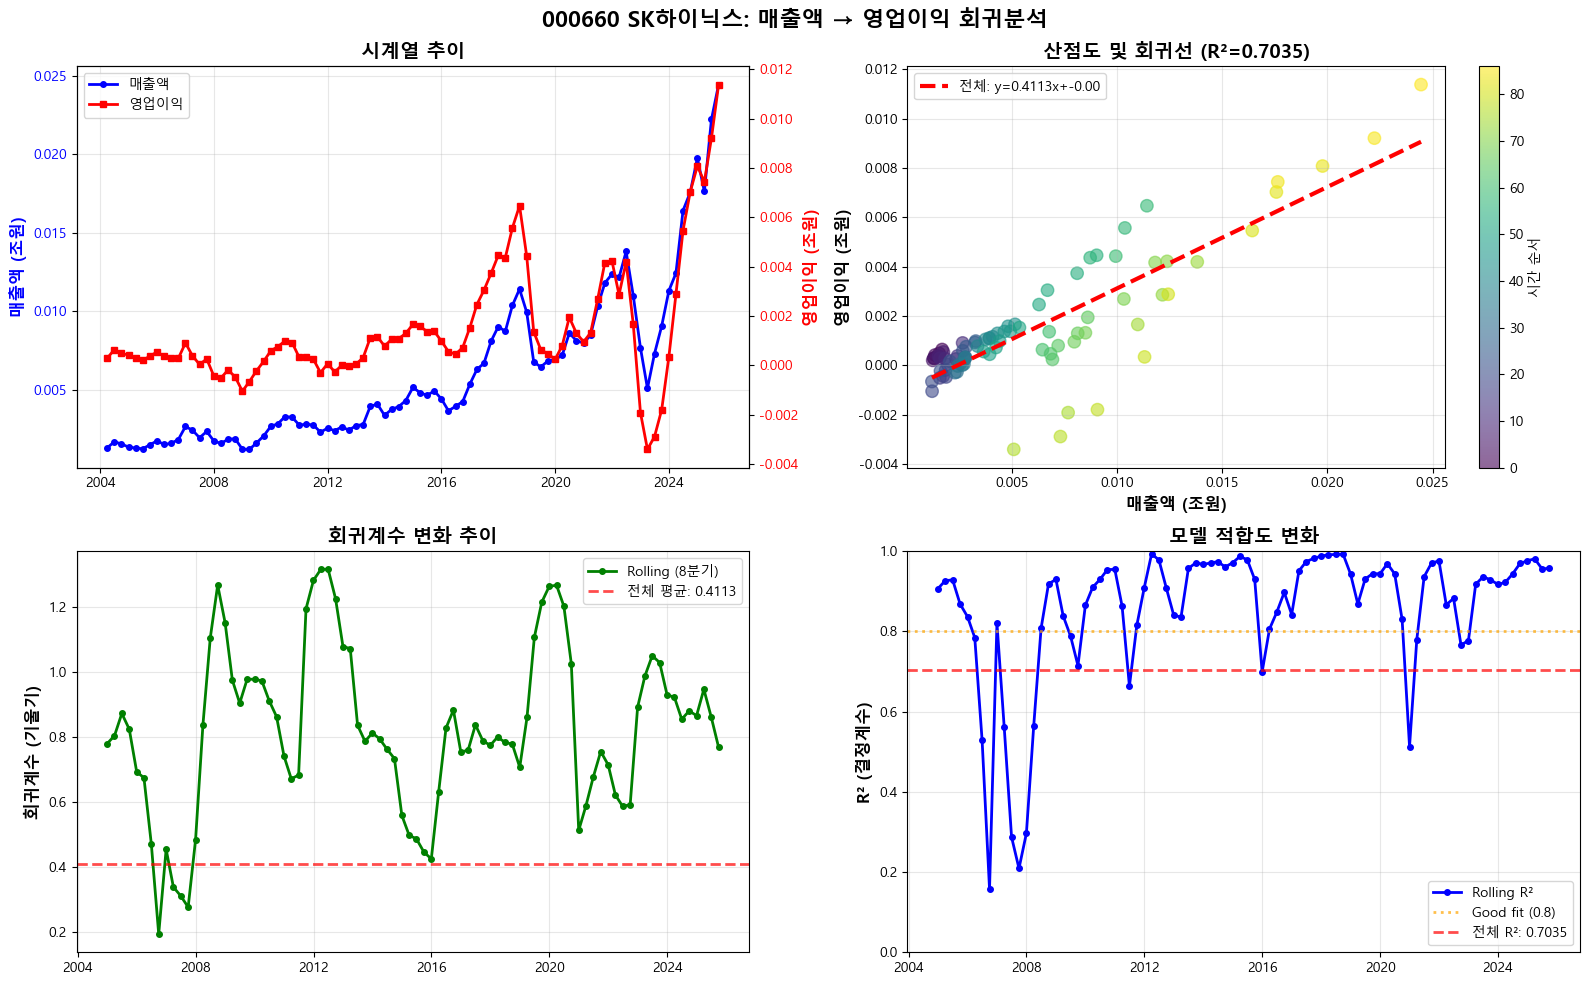

✅ 그래프 생성 완료!

📊 회귀계수 안정성 분석

[Rolling Window (8분기)]
  평균:        0.823333
  표준편차:    0.251810
  변동계수:    0.3058
  최소값:      0.194698
  최대값:      1.315815

[R² 통계]
  평균:        0.8564
  중앙값:      0.9240
  최소값:      0.1576
  최대값:      0.9929

🎯 최근 5개 분기 예측 vs 실제

📅 2024-09-30
  매출액:          0.02 조원
  실제 영업이익:   0.01 조원
  예측 영업이익:   0.01 조원
  오차:            0.00 조원 (+5.7%)

📅 2024-12-31
  매출액:          0.02 조원
  실제 영업이익:   0.01 조원
  예측 영업이익:   0.01 조원
  오차:            -0.00 조원 (-3.6%)

📅 2025-03-31
  매출액:          0.02 조원
  실제 영업이익:   0.01 조원
  예측 영업이익:   0.01 조원
  오차:            0.00 조원 (+8.2%)

📅 2025-06-30
  매출액:          0.02 조원
  실제 영업이익:   0.01 조원
  예측 영업이익:   0.01 조원
  오차:            -0.00 조원 (-12.6%)

📅 2025-09-30
  매출액:          0.02 조원
  실제 영업이익:   0.01 조원
  예측 영업이익:   0.01 조원
  오차:            -0.00 조원 (-2.3%)

✅ 분석 완료!


In [5]:
# ============================================================
# Jupyter Notebook 셀에 이 코드를 통째로 복사해서 실행하세요
# ============================================================

import sys
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 1. 프로젝트 경로 및 DB 설정
# ============================================================

PROJECT_ROOT = Path(r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ============================================================
# 2. 데이터 수집
# ============================================================

ticker = "000660"  # SK하이닉스
tickers = [ticker]

print(f"📊 데이터 수집 중: {ticker}")
long_df, errors = build_long_for_tickers(
    db_info=db_info,
    tickers=tickers,
    verbose=False
)

if errors:
    print(f"⚠️ 에러: {errors}")
else:
    print(f"✅ 데이터 수집 완료: {len(long_df)} rows")

# ============================================================
# 3. 매출액, 영업이익만 추출하여 Wide Format으로 변환
# ============================================================

print(f"\n📈 매출액, 영업이익 추출 중...")

# ticker 필터링
df_ticker = long_df[long_df['ticker'] == ticker].copy()

# 매출액, 영업이익만 필터링
df_filtered = df_ticker[df_ticker['indicator'].isin(['매출액', '영업이익'])].copy()

# pivot: date를 index로, indicator를 컬럼으로
df_wide = df_filtered.pivot_table(
    index='date',
    columns='indicator',
    values='value',
    aggfunc='first'
).sort_index()

# NaN 제거 (매출액과 영업이익이 모두 있는 행만)
df_wide = df_wide.dropna()

print(f"✅ 추출 완료: {len(df_wide)} 분기")
print(f"   기간: {df_wide.index.min().date()} ~ {df_wide.index.max().date()}")
print(f"\n최근 5개 데이터:")
print(df_wide.tail())

# ============================================================
# 4. Rolling Window 회귀분석 함수
# ============================================================

def rolling_regression_analysis(df, x_col='매출액', y_col='영업이익', window=8):
    """
    Rolling window 회귀분석

    Parameters
    ----------
    df : DataFrame with date index, columns=[x_col, y_col]
    x_col : 독립변수 (X)
    y_col : 종속변수 (Y)
    window : 회귀분석에 사용할 분기 수

    Returns
    -------
    DataFrame with columns: coefficient, intercept, r2, n_samples
    """
    results = []

    for i in range(len(df)):
        # 최근 window개 분기 데이터 선택
        start_idx = max(0, i - window + 1)
        window_data = df.iloc[start_idx:i+1]

        # 최소 4분기 이상 있어야 회귀분석
        if len(window_data) < 4:
            results.append({
                'date': df.index[i],
                'coefficient': np.nan,
                'intercept': np.nan,
                'r2': np.nan,
                'n_samples': len(window_data)
            })
            continue

        # X, Y 추출
        X = window_data[[x_col]].values
        y = window_data[y_col].values

        # 회귀분석
        model = LinearRegression()
        model.fit(X, y)

        # 예측 및 R²
        y_pred = model.predict(X)
        r2 = r2_score(y, y_pred)

        results.append({
            'date': df.index[i],
            'coefficient': model.coef_[0],      # 기울기
            'intercept': model.intercept_,      # 절편
            'r2': r2,                            # 결정계수
            'n_samples': len(window_data)       # 샘플 수
        })

    results_df = pd.DataFrame(results)
    results_df.set_index('date', inplace=True)

    return results_df


# ============================================================
# 5. Rolling 회귀분석 실행 (최근 8분기 기준)
# ============================================================

print(f"\n🔍 Rolling 회귀분석 수행 중 (최근 8분기 기준)...")

rolling_results = rolling_regression_analysis(
    df_wide,
    x_col='매출액',
    y_col='영업이익',
    window=8
)

print(f"✅ 회귀분석 완료")
print(f"\n최근 10개 분기 결과:")
print(rolling_results.tail(10))

# 최근 회귀식 출력
latest = rolling_results.dropna().iloc[-1]
print(f"\n" + "="*60)
print(f"📌 최신 회귀식 ({latest.name.date()})")
print(f"="*60)
print(f"영업이익 = {latest['coefficient']:.6f} × 매출액 + {latest['intercept']:.2e}")
print(f"")
print(f"해석:")
print(f"  - 매출액이 1조원 증가하면 영업이익은 {latest['coefficient']*1e12:.0f}원 증가")
print(f"  - R² = {latest['r2']:.4f} (설명력 {latest['r2']*100:.1f}%)")
print(f"  - 사용한 분기 수: {int(latest['n_samples'])}분기")
print(f"="*60)

# ============================================================
# 6. 전체 기간 회귀분석 (비교용)
# ============================================================

print(f"\n🔍 전체 기간 회귀분석...")

X_all = df_wide[['매출액']].values
y_all = df_wide['영업이익'].values

model_all = LinearRegression()
model_all.fit(X_all, y_all)

y_pred_all = model_all.predict(X_all)
r2_all = r2_score(y_all, y_pred_all)

print(f"\n" + "="*60)
print(f"📌 전체 기간 회귀식")
print(f"="*60)
print(f"영업이익 = {model_all.coef_[0]:.6f} × 매출액 + {model_all.intercept_:.2e}")
print(f"R² = {r2_all:.4f}")
print(f"사용한 분기 수: {len(df_wide)}분기")
print(f"="*60)

# ============================================================
# 7. 시각화
# ============================================================

print(f"\n📊 그래프 생성 중...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'{ticker} SK하이닉스: 매출액 → 영업이익 회귀분석',
             fontsize=16, fontweight='bold')

# ----------------------------------------
# 그래프 1: 매출액과 영업이익 시계열
# ----------------------------------------
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()

line1 = ax1.plot(df_wide.index, df_wide['매출액']/1e12,
                 'b-', marker='o', markersize=4, linewidth=2, label='매출액')
line2 = ax1_twin.plot(df_wide.index, df_wide['영업이익']/1e12,
                      'r-', marker='s', markersize=4, linewidth=2, label='영업이익')

ax1.set_ylabel('매출액 (조원)', color='b', fontsize=12, fontweight='bold')
ax1_twin.set_ylabel('영업이익 (조원)', color='r', fontsize=12, fontweight='bold')
ax1.set_title('시계열 추이', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='y', labelcolor='b')
ax1_twin.tick_params(axis='y', labelcolor='r')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

# ----------------------------------------
# 그래프 2: 산점도 및 회귀선
# ----------------------------------------
ax2 = axes[0, 1]

# 산점도
scatter = ax2.scatter(df_wide['매출액']/1e12, df_wide['영업이익']/1e12,
                     alpha=0.6, s=80, c=range(len(df_wide)), cmap='viridis')

# 전체 기간 회귀선
x_range = np.linspace(df_wide['매출액'].min(), df_wide['매출액'].max(), 100)
y_pred_line = model_all.predict(x_range.reshape(-1, 1))
ax2.plot(x_range/1e12, y_pred_line/1e12, 'r--', linewidth=3,
         label=f'전체: y={model_all.coef_[0]:.4f}x+{model_all.intercept_/1e12:.2f}')

ax2.set_xlabel('매출액 (조원)', fontsize=12, fontweight='bold')
ax2.set_ylabel('영업이익 (조원)', fontsize=12, fontweight='bold')
ax2.set_title(f'산점도 및 회귀선 (R²={r2_all:.4f})', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 컬러바
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('시간 순서', fontsize=10)

# ----------------------------------------
# 그래프 3: 회귀계수 변화
# ----------------------------------------
ax3 = axes[1, 0]

ax3.plot(rolling_results.index, rolling_results['coefficient'],
         'g-', marker='o', markersize=4, linewidth=2, label='Rolling (8분기)')
ax3.axhline(y=model_all.coef_[0], color='r', linestyle='--',
           linewidth=2, alpha=0.7, label=f'전체 평균: {model_all.coef_[0]:.4f}')

ax3.set_ylabel('회귀계수 (기울기)', fontsize=12, fontweight='bold')
ax3.set_title('회귀계수 변화 추이', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# ----------------------------------------
# 그래프 4: R² 변화
# ----------------------------------------
ax4 = axes[1, 1]

ax4.plot(rolling_results.index, rolling_results['r2'],
         'b-', marker='o', markersize=4, linewidth=2, label='Rolling R²')
ax4.axhline(y=0.8, color='orange', linestyle=':', linewidth=2,
           alpha=0.7, label='Good fit (0.8)')
ax4.axhline(y=r2_all, color='r', linestyle='--', linewidth=2,
           alpha=0.7, label=f'전체 R²: {r2_all:.4f}')

ax4.set_ylabel('R² (결정계수)', fontsize=12, fontweight='bold')
ax4.set_title('모델 적합도 변화', fontsize=14, fontweight='bold')
ax4.set_ylim([0, 1])
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✅ 그래프 생성 완료!")

# ============================================================
# 8. 안정성 분석
# ============================================================

print(f"\n" + "="*60)
print(f"📊 회귀계수 안정성 분석")
print(f"="*60)

rolling_coef = rolling_results['coefficient'].dropna()

print(f"\n[Rolling Window (8분기)]")
print(f"  평균:        {rolling_coef.mean():.6f}")
print(f"  표준편차:    {rolling_coef.std():.6f}")
print(f"  변동계수:    {rolling_coef.std() / rolling_coef.mean():.4f}")
print(f"  최소값:      {rolling_coef.min():.6f}")
print(f"  최대값:      {rolling_coef.max():.6f}")

rolling_r2 = rolling_results['r2'].dropna()
print(f"\n[R² 통계]")
print(f"  평균:        {rolling_r2.mean():.4f}")
print(f"  중앙값:      {rolling_r2.median():.4f}")
print(f"  최소값:      {rolling_r2.min():.4f}")
print(f"  최대값:      {rolling_r2.max():.4f}")

# ============================================================
# 9. 최근 5개 분기 예측 vs 실제
# ============================================================

print(f"\n" + "="*60)
print(f"🎯 최근 5개 분기 예측 vs 실제")
print(f"="*60)

recent_5 = df_wide.tail(5)

for idx in recent_5.index:
    # 해당 시점의 회귀계수 가져오기
    if idx not in rolling_results.index:
        continue

    coef = rolling_results.loc[idx, 'coefficient']
    intercept = rolling_results.loc[idx, 'intercept']

    if pd.isna(coef):
        continue

    # 예측
    actual_sales = recent_5.loc[idx, '매출액']
    actual_profit = recent_5.loc[idx, '영업이익']
    predicted_profit = coef * actual_sales + intercept

    error = actual_profit - predicted_profit
    error_pct = (error / actual_profit) * 100 if actual_profit != 0 else 0

    print(f"\n📅 {idx.date()}")
    print(f"  매출액:          {actual_sales/1e12:.2f} 조원")
    print(f"  실제 영업이익:   {actual_profit/1e12:.2f} 조원")
    print(f"  예측 영업이익:   {predicted_profit/1e12:.2f} 조원")
    print(f"  오차:            {error/1e12:.2f} 조원 ({error_pct:+.1f}%)")

print(f"\n" + "="*60)
print(f"✅ 분석 완료!")
print(f"="*60)